In [2]:
import torch
from torchvision import datasets, transforms

In [3]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"
data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
data_dir3 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"

In [4]:
dataset1 = datasets.ImageFolder(data_dir1)
dataset2 = datasets.ImageFolder(data_dir2)
dataset3 = datasets.ImageFolder(data_dir3)

In [5]:
datasets_all = torch.utils.data.ConcatDataset([dataset1, dataset2, dataset3])
data_train, data_test = torch.utils.data.random_split(datasets_all, [0.8, 0.2])

img, label = data_train[2000]

In [6]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.CenterCrop(60),
     transforms.RandomRotation(180),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.CenterCrop(60),
     transforms.ToTensor()
    ] 
)

In [7]:
transformed_img = train_transform(img)
print(transformed_img.shape)

torch.Size([3, 60, 60])


In [8]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [9]:
train_data = TransformDataset(data_train, train_transform)

In [10]:
test_data = TransformDataset(data_test, test_transform)

In [11]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [12]:
for img, idx in test_loader:
    print(img.shape)
    print(idx.shape)

torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([84, 3, 60, 60])
torch.Size([84])


In [13]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset1.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

(60, 60, 3)


NameError: name 'dataset' is not defined

In [ ]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [38]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(10800, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = "cuda"
model = model.to(device)

In [41]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.2
)

loss_list = []
loss_test_list = []
for i in range(3):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

         
        loss_test_list.append(loss.cpu().item())

loss: 0.6884085536003113
loss: 1028.741455078125
loss: 24.036006927490234
loss: 4.492253303527832
loss: 25.435253143310547
loss: 118.81878662109375
loss: 8.650749206542969
loss: 66.7088623046875
loss: 64.143310546875
loss: 49.09320831298828
loss: 13.220827102661133
loss: 0.772540271282196
loss: 0.6387472748756409
loss: 0.621061384677887
loss: 0.64211505651474
loss: 0.6574418544769287
loss: 0.6080406308174133
loss: 0.653380274772644
loss: 0.6185169816017151
loss: 0.6177189350128174
loss: 0.642280101776123
loss: 0.608041524887085
loss: 0.6460440158843994
loss: 0.6608569622039795
loss: 0.6563277244567871
loss: 0.6251519918441772
loss: 0.619385838508606
loss: 0.6328444480895996
loss: 0.6185741424560547
loss: 0.6359114050865173
loss: 0.6691104173660278
loss: 0.602982759475708
loss: 0.5935665369033813
loss: 0.6081773638725281
loss: 0.6084533333778381
loss: 0.6179744005203247
loss: 0.630669116973877
loss: 0.665579617023468
loss: 0.6116270422935486
loss: 0.6148006916046143
loss: 0.598932266235

KeyboardInterrupt: 

In [37]:
img, label = train_data[57]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(nn.Softmax()(prediction))



1
tensor([[0.7156, 0.2844]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


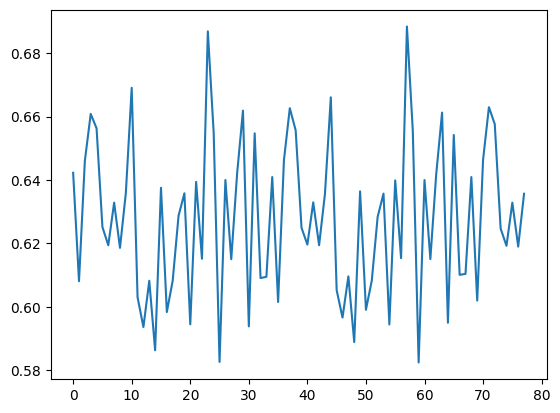

In [47]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

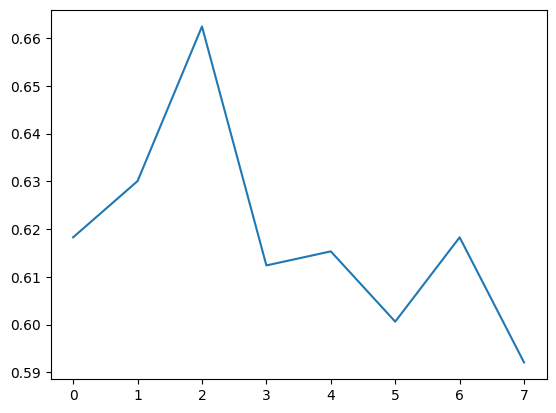

In [48]:
plt.plot(new_test_list)